# Files for each user

In [15]:
import zipfile
zip_path = r'D:\PRIDE dataset.zip'

with zipfile.ZipFile(zip_path, 'r') as outer_zip:
    with outer_zip.open('PRIDE dataset/PRIDE dataset/User1.zip') as user_file:
        with zipfile.ZipFile(user_file , 'r') as inner_zip:
            files = inner_zip.namelist()
            print(f"Inside User1.zip:")
            for f in files:
                print(f)

Inside User1.zip:
User1/
User1/Dataset/
User1/Dataset/ACDS.csv
User1/Dataset/NCDS.csv
User1/FiveFoldCrossValidation/
User1/FiveFoldCrossValidation/Fold1/
User1/FiveFoldCrossValidation/Fold1/testing.csv
User1/FiveFoldCrossValidation/Fold1/training.csv
User1/FiveFoldCrossValidation/Fold2/
User1/FiveFoldCrossValidation/Fold2/testing.csv
User1/FiveFoldCrossValidation/Fold2/training.csv
User1/FiveFoldCrossValidation/Fold3/
User1/FiveFoldCrossValidation/Fold3/testing.csv
User1/FiveFoldCrossValidation/Fold3/training.csv
User1/FiveFoldCrossValidation/Fold4/
User1/FiveFoldCrossValidation/Fold4/testing.csv
User1/FiveFoldCrossValidation/Fold4/training.csv
User1/FiveFoldCrossValidation/Fold5/
User1/FiveFoldCrossValidation/Fold5/testing.csv
User1/FiveFoldCrossValidation/Fold5/training.csv


- The PRIDE dataset is highly nested (Zips stored inside another Zip) so this lets you extract files straight into your computer's RAM without manually extracting files to your hard drive.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os
import gc # garbage collector

In [16]:
with zipfile.ZipFile(zip_path, 'r') as outer_zip:
    with outer_zip.open('PRIDE dataset/PRIDE dataset/User1.zip') as user_file:
        with zipfile.ZipFile(user_file , 'r') as inner_zip:
            
            with inner_zip.open('User1/Dataset/NCDS.csv') as f: # Normal
                df_ncds = pd.read_csv(f, header=None)
            
            with inner_zip.open('User1/Dataset/ACDS.csv') as f: #anomaly
                df_acds = pd.read_csv(f, header=None)

print(f"NCDS: {df_ncds.shape}")
print(f"ACDS: {df_acds.shape}")
print(f"\n first 3 rows in ACDS:")
print(df_acds.head(3))

NCDS: (466175, 26)
ACDS: (770, 27)

 first 3 rows in ACDS:
         0         1         2         3         4         5         6   \
0  0.947559  0.001756 -0.069775  0.008501  0.300488  0.008228 -0.097561   
1  0.947815  0.007233 -0.068054  0.006363  0.294922  0.004707  0.514482   
2  0.953674  0.013057 -0.054077  0.016676  0.305725  0.026543  0.137195   

         7         8         9   ...        17  18     19   20   21   22   23  \
0  2.141052 -0.146341  0.853963  ...  0.006800  91  32.17  0.0  0.0  0.0  0.0   
1  1.341848 -0.141006  0.295959  ...  0.004165  91  32.17  0.0  0.0  0.0  0.0   
2  4.964670 -0.038110  1.090206  ...  0.010766  91  32.17  0.0  0.0  0.0  0.0   

    24  25            26  
0  0.0   0  fall_back_01  
1  0.0   0  fall_back_01  
2  0.0   0  fall_back_01  

[3 rows x 27 columns]


- (header = None) because we don't have column names so the first row is data not column names
- imbalance

In [4]:
print(df_acds.iloc[:, -1].value_counts())
# 13 abnormal types

26
fight                    156
fall_back_01              95
stairs                    70
rushing_100m_01           58
fall_back_03              48
rushing_100m_02           48
fall_forth_01             47
fall_forth_03             47
holding_out_breath_02     45
holding_out_breath_03     42
fall_back_02              41
fall_forth_02             37
holding_out_breath_01     36
Name: count, dtype: int64


- extra column in ACDS to determine the anomaly type

In [5]:
with zipfile.ZipFile(zip_path, 'r') as outer_zip:
    with outer_zip.open('PRIDE dataset/PRIDE dataset/User1.zip') as user_file:
        with zipfile.ZipFile(user_file , 'r') as inner_zip:
            with inner_zip.open('User1/FiveFoldCrossValidation/Fold1/training.csv') as f:
                df_train = pd.read_csv(f, header=None)
            with inner_zip.open('User1/FiveFoldCrossValidation/Fold1/testing.csv') as f:
                df_test = pd.read_csv(f, header=None)

print(f"1st fold Train: {df_train.shape}")
print(f"1st fold Test: {df_test.shape}")
print(f"\n first 3 rows in train:")
print(df_train.head(3))
print(f"\n first 3 rows in test:")
print(df_test.head(3))

1st fold Train: (372939, 26)
1st fold Test: (93993, 27)

 first 3 rows in train:
         0         1         2         3         4         5         6   \
0 -0.561066  0.001792 -0.737640  0.001320 -0.389832  0.002883  0.483994   
1 -0.559998  0.000760 -0.739807  0.001290 -0.390106  0.002628  0.442073   
2 -0.559357  0.001108 -0.739777  0.001698 -0.391266  0.003334  0.419207   

         7         8         9   ...        16        17  18     19   20   21  \
0  0.413680 -0.483994  0.107183  ... -0.389832  0.002883  70  34.02  0.0  0.0   
1  0.314261 -0.602134  0.179561  ... -0.390106  0.002628  69  34.02  0.0  0.0   
2  0.286305 -0.644055  0.129741  ... -0.391266  0.003334  69  34.02  0.0  0.0   

    22   23   24  25  
0  0.0  0.0  0.0   0  
1  0.0  0.0  0.0   0  
2  0.0  0.0  0.0   0  

[3 rows x 26 columns]

 first 3 rows in test:
         0         1         2         3         4         5          6   \
0 -0.631104  0.000000 -0.750488  0.000000  0.233643  0.000000   0.213415   
1 

# 5 Folds

In [2]:
output_dir = r'D:\PRIDE_Processed_Folds'

In [ ]:
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

feature_names = [
    'gyro_acc_x_mean', 'gyro_acc_x_std', 'gyro_acc_y_mean', 'gyro_acc_y_std', 'gyro_acc_z_mean', 'gyro_acc_z_std',
    'gyro_vel_x_mean', 'gyro_vel_x_std', 'gyro_vel_y_mean', 'gyro_vel_y_std', 'gyro_vel_z_mean', 'gyro_vel_z_std',
    'acc_x_mean', 'acc_x_std', 'acc_y_mean', 'acc_y_std', 'acc_z_mean', 'acc_z_std',
    'heart_rate', 'skin_temp', 
    'delta_steps', 'delta_distance', 'speed', 'pace', 'delta_calories', 'uv'
]

for fold_num in range(1, 6):
    print(f"\n🔄 جاري تجميع وتجهيز [Fold {fold_num}] للـ 23 مستخدم...")
    
    train_list = []
    test_list = []
    
    with zipfile.ZipFile(zip_path, 'r') as outer_zip:
        for user_id in range(1, 24):
            user_zip_name = f'PRIDE dataset/PRIDE dataset/User{user_id}.zip'
            
            try:
                with outer_zip.open(user_zip_name) as user_file:
                    with zipfile.ZipFile(user_file, 'r') as inner_zip:
                        
                        train_path = f'User{user_id}/FiveFoldCrossValidation/Fold{fold_num}/training.csv'
                        with inner_zip.open(train_path) as f:
                            df_user_train = pd.read_csv(f, header=None)
                            df_user_train.columns = feature_names
                            df_user_train['Label'] = 0
                            train_list.append(df_user_train)
                        
                        test_path = f'User{user_id}/FiveFoldCrossValidation/Fold{fold_num}/testing.csv'
                        with inner_zip.open(test_path) as f:
                            df_user_test = pd.read_csv(f, header=None)
                            df_user_test.columns = feature_names + ['Label']
                            test_list.append(df_user_test)
                            
            except Exception as e:
                print(f'Error in User{user_id}/FiveFoldCrossValidation/Fold{fold_num}')

    
    df_fold_train = pd.concat(train_list, ignore_index=True)
    df_fold_test = pd.concat(test_list, ignore_index=True)
    
    del train_list
    del test_list
    gc.collect()
    
    label_map = {'typical': 0, 'atypical': 1, 0: 0, 1: 1}
    df_fold_test['Label'] = df_fold_test['Label'].map(label_map)
    
    train_file_path = os.path.join(output_dir, f'fold_{fold_num}_train.csv')
    test_file_path = os.path.join(output_dir, f'fold_{fold_num}_test.csv')
    
    df_fold_train.to_csv(train_file_path, index=False)
    df_fold_test.to_csv(test_file_path, index=False)
    
    print(f"✅ تم حفظ Fold {fold_num} بنجاح! (Train: {df_fold_train.shape} | Test: {df_fold_test.shape})")
    
    del df_fold_train
    del df_fold_test
    gc.collect()

# EDA

In [3]:
df_train = pd.read_csv(os.path.join(output_dir, 'fold_1_train.csv'))
df_test = pd.read_csv(os.path.join(output_dir, 'fold_1_test.csv'))

print(f'Fold 1')
print(f"   -> Train: {df_train.shape} | Test: {df_test.shape}")

Fold 1
   -> Train: (5933470, 27) | Test: (1499245, 27)


In [4]:
print(f"   ->  Nulls in Train: {df_train.isnull().sum().sum()}")
print(f"   ->  Nulls in Test:  {df_test.isnull().sum().sum()}")

print("\n Duplicate Rows:")
train_duplicates = df_train.duplicated().sum()
test_duplicates = df_test.duplicated().sum()
print(f"   -> Train: {train_duplicates} ")
print(f"   -> Test:  {test_duplicates} ")

   ->  Nulls in Train: 0
   ->  Nulls in Test:  0

 Duplicate Rows:
   -> Train: 796 
   -> Test:  219 


In [ ]:
print(df_train[['gyro_acc_x_mean', 'gyro_acc_x_std', 'gyro_acc_y_mean',
    'gyro_acc_y_std', 'gyro_acc_z_mean', 'gyro_acc_z_std',
    'gyro_vel_x_mean', 'gyro_vel_x_std', 'gyro_vel_y_mean',
    'gyro_vel_y_std', 'gyro_vel_z_mean', 'gyro_vel_z_std']].describe())

       gyro_acc_x_mean  gyro_acc_x_std  gyro_acc_y_mean  gyro_acc_y_std  \
count     5.932674e+06    5.932674e+06     5.932674e+06    5.932674e+06   
mean     -5.352420e-02    4.573457e-02     2.614417e-02    5.503991e-02   
std       4.936960e-01    1.031661e-01     5.763219e-01    1.186897e-01   
min      -2.277252e+00    0.000000e+00    -2.887238e+00    0.000000e+00   
25%      -3.967285e-01    1.483795e-03    -4.630737e-01    1.717409e-03   
50%      -8.904157e-02    4.282911e-03     4.617310e-02    6.124767e-03   
75%       2.309876e-01    3.870888e-02     5.043640e-01    5.534942e-02   
max       6.223145e+00    4.562537e+00     5.511719e+00    4.728910e+00   

       gyro_acc_z_mean  gyro_acc_z_std  gyro_vel_x_mean  gyro_vel_x_std  \
count     5.932674e+06    5.932674e+06     5.932674e+06    5.932674e+06   
mean      1.765492e-01    5.187660e-02    -4.465134e-01    1.578539e+01   
std       6.200057e-01    1.061737e-01     1.678870e+01    3.521321e+01   
min      -3.655151e+00  

In [8]:
df_train.columns

Index(['gyro_acc_x_mean', 'gyro_acc_x_std', 'gyro_acc_y_mean',
       'gyro_acc_y_std', 'gyro_acc_z_mean', 'gyro_acc_z_std',
       'gyro_vel_x_mean', 'gyro_vel_x_std', 'gyro_vel_y_mean',
       'gyro_vel_y_std', 'gyro_vel_z_mean', 'gyro_vel_z_std', 'acc_x_mean',
       'acc_x_std', 'acc_y_mean', 'acc_y_std', 'acc_z_mean', 'acc_z_std',
       'heart_rate', 'skin_temp', 'delta_steps', 'delta_distance', 'speed',
       'pace', 'delta_calories', 'uv', 'Label'],
      dtype='str')

In [ ]:
print(df_train[['acc_x_mean',
    'acc_x_std', 'acc_y_mean', 'acc_y_std', 'acc_z_mean', 'acc_z_std',
    'heart_rate', 'skin_temp', 'delta_steps', 'delta_distance', 'speed',
    'pace', 'delta_calories', 'uv', 'Label']].describe())

         acc_x_mean     acc_x_std    acc_y_mean     acc_y_std    acc_z_mean  \
count  5.932674e+06  5.932674e+06  5.932674e+06  5.932674e+06  5.932674e+06   
mean  -5.352656e-02  4.572695e-02  2.613843e-02  5.503429e-02  1.765623e-01   
std    4.937044e-01  1.030768e-01  5.763265e-01  1.186441e-01  6.200194e-01   
min   -2.361258e+00  0.000000e+00 -2.696320e+00  0.000000e+00 -3.655151e+00   
25%   -3.967285e-01  1.483795e-03 -4.631042e-01  1.717410e-03 -3.159485e-01   
50%   -8.901978e-02  4.282912e-03  4.617746e-02  6.123512e-03  2.669983e-01   
75%    2.310364e-01  3.871406e-02  5.043945e-01  5.533650e-02  7.560730e-01   
max    6.800700e+00  3.835525e+00  4.356689e+00  5.975968e+00  3.221558e+00   

          acc_z_std    heart_rate     skin_temp   delta_steps  delta_distance  \
count  5.932674e+06  5.932674e+06  5.932674e+06  5.932674e+06    5.932674e+06   
mean   5.187260e-02  7.136229e+01  3.354773e+01  2.418316e-01    9.929609e+00   
std    1.061507e-01  1.183206e+01  3.267559e+

- noise in heart_rate (5) 
- noise in skip_temp (0)
(Outliers):
- skin_temp 46.09
- speed 416
- pace 3225
- delta setps 309374 
- delta distance 1125838
- delta calories 138,616 
- most activties are indoors

C:\Users\Roaya\AppData\Local\Temp\ipykernel_23840\1405303398.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df_test['Label'], palette='coolwarm')


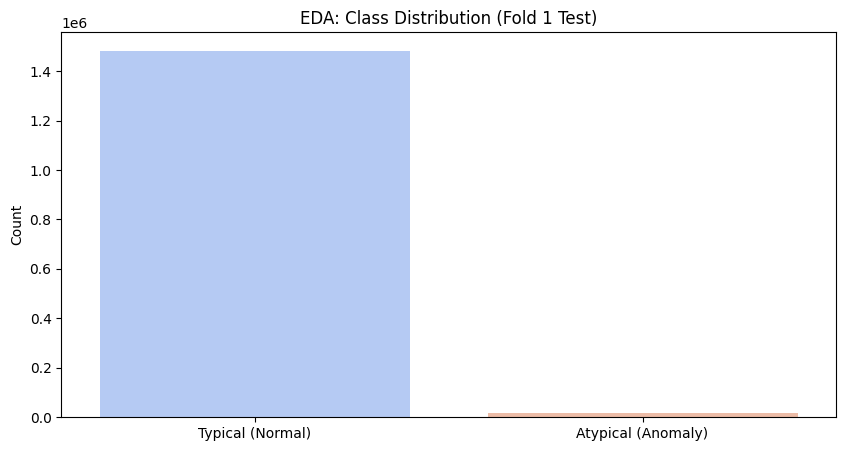

In [27]:
plt.figure(figsize=(10, 5))
sns.countplot(x=df_test['Label'], palette='coolwarm')
plt.title('EDA: Class Distribution (Fold 1 Test)')
plt.xticks([0,1],['Typical (Normal)', 'Atypical (Anomaly)'])
plt.xlabel(None)
plt.ylabel('Count')
plt.show()

> High Imbalance in label

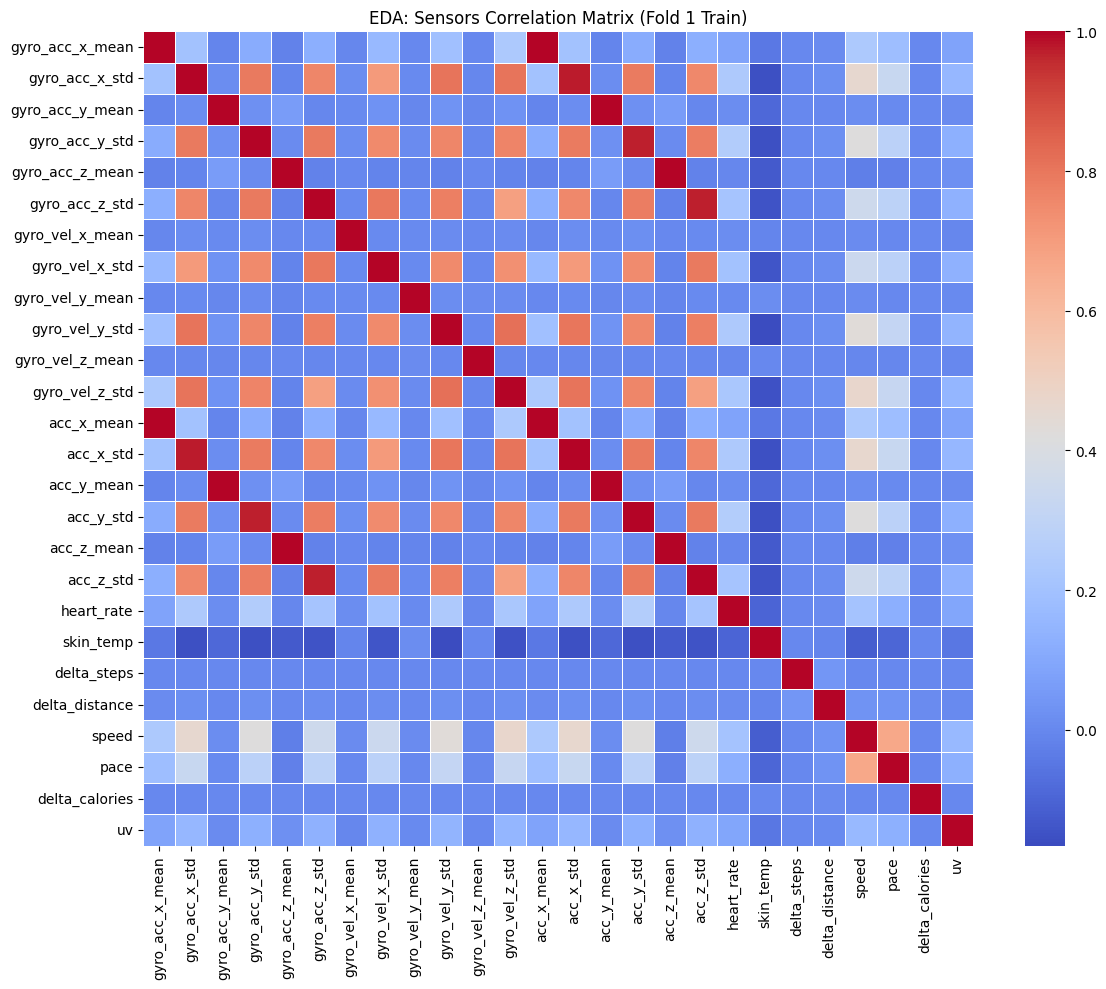

In [ ]:
df_sample = df_train.drop(columns=['Label'])
corr_matrix = df_sample.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, cmap='coolwarm', annot=False, linewidths=0.5)
plt.title('EDA: Sensors Correlation Matrix (Fold 1 Train)')
plt.tight_layout()
plt.show()

> Strong corr between Accelerometer & Gyro_acc mean 
<br>
ده معناه إن مستشعر التسارع العادي ومستشعر الجايرسكوب بيقرأوا حركات متزامنة تماماً في نفس الاتجاه.
<br>
Strong corr between Accelerometer & Gyro_acc mean std
<br>
وده معناه إنه لما الحركة بتبقى عنيفة أو فيها تذبذب في مستشعر، باقي المستشعرات بتلقط التذبذب ده في نفس الوقت.
<br>
a corr between pace & spead

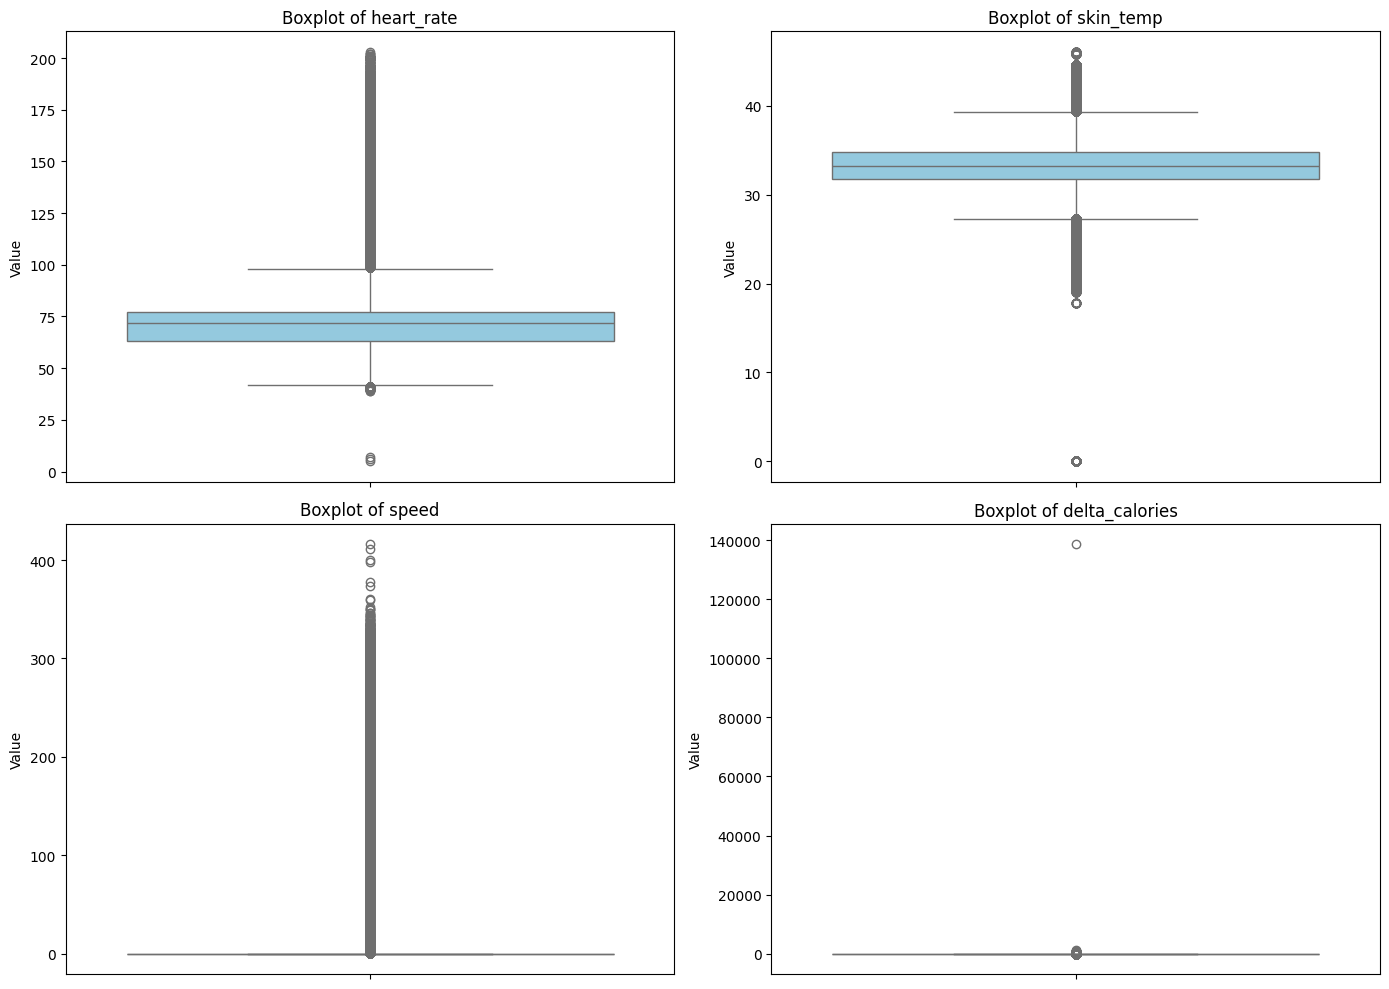

In [ ]:
features_to_plot = ['heart_rate', 'skin_temp', 'speed', 'delta_calories']

plt.figure(figsize=(14, 10))

for i, col in enumerate(features_to_plot, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(y=df_train[col], color='skyblue')
    plt.title(f'Boxplot of {col}')
    plt.ylabel('Value')

plt.tight_layout()
plt.show()

In [ ]:
for col in features_to_plot:
    print(f"   -> {col}: {df_train[col].skew():.2f}")

   -> heart_rate: 1.35
   -> skin_temp: 0.58
   -> speed: 4.56
   -> delta_calories: 2431.30


In [15]:
for col in features_to_plot:
    print(f"   -> {col}: {df_test[col].skew():.2f}")

   -> heart_rate: 1.34
   -> skin_temp: -0.04
   -> speed: 5.78
   -> delta_calories: 336.75


> مقارنة معامل الالتواء (Skewness) بين مجموعتي التدريب والاختبار، نجد تقارباً كبيراً في المؤشرات الحيوية مما يضمن استقرار النمذجة (Generalization). أما الاختلاف الحاد في ميزة السعرات الحرارية والسرعة فيؤكد أن الـ Extreme Outliers تظهر عشوائياً بكثافة مختلفة بين الفولدز، وهو ما يعزز قرارنا بالاعتماد على StandardScaler لتوحيد المقاييس.

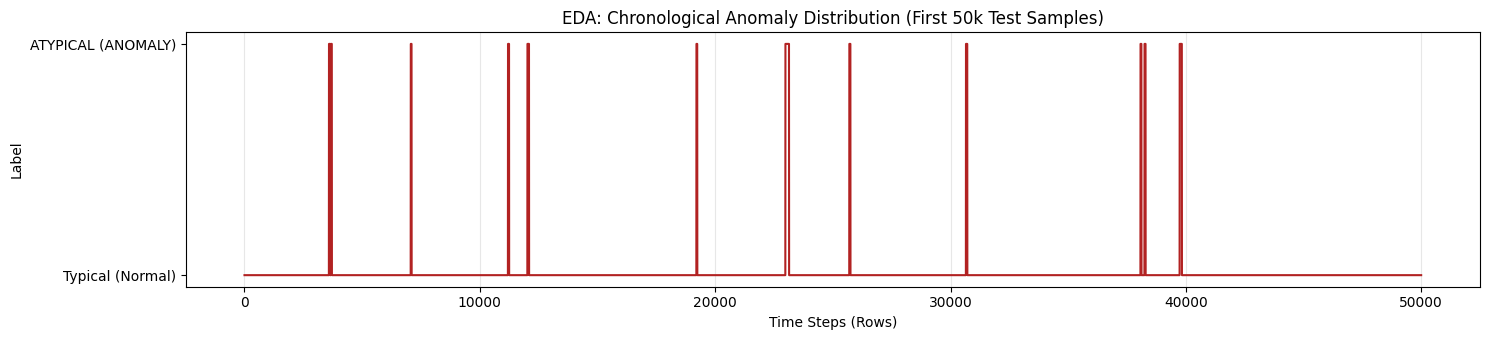

In [6]:
sample_range = 50000

plt.figure(figsize=(15, 3.5))
plt.plot(df_test['Label'].values[:sample_range], color='firebrick')
plt.title('EDA: Chronological Anomaly Distribution (First 50k Test Samples)')
plt.xlabel('Time Steps (Rows)')
plt.ylabel('Label')
plt.yticks([0, 1], ['Typical (Normal)', 'ATYPICAL (ANOMALY)'])
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()